<a href="https://colab.research.google.com/github/SelvaRameshKumar/Selvakumar_projects/blob/main/Dominos_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import pandas as pd

sales_df = pd.read_excel(
    "/content/drive/MyDrive/Dominos_project/Pizza_Sale.xlsx"
)

ingredients_df = pd.read_excel(
    "/content/drive/MyDrive/Dominos_project/Pizza_ingredients.xlsx"
)


In [ ]:
sales_df.head()
ingredients_df.head()


,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
0,bbq_ckn_l,The Barbecue Chicken Pizza,Barbecued Chicken,40.0
1,bbq_ckn_l,The Barbecue Chicken Pizza,Red Peppers,15.0
2,bbq_ckn_l,The Barbecue Chicken Pizza,Green Peppers,20.0
3,bbq_ckn_l,The Barbecue Chicken Pizza,Tomatoes,30.0
4,bbq_ckn_l,The Barbecue Chicken Pizza,Red Onions,60.0


In [ ]:
print(sales_df.shape)
print(sales_df.columns)

print(ingredients_df.shape)
print(ingredients_df.columns)


(48620, 12)
Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')
(518, 4)
Index(['pizza_name_id', 'pizza_name', 'pizza_ingredients',
       'Items_Qty_In_Grams'],
      dtype='object')


In [ ]:
sales_df.isna().sum()


,0
pizza_id,0
order_id,0
pizza_name_id,16
quantity,0
order_date,0
order_time,0
unit_price,0
total_price,7
pizza_size,0
pizza_category,23


In [ ]:
sales_df = sales_df.dropna(
    subset=['quantity', 'order_date', 'pizza_name_id']
)


In [ ]:
sales_df['order_date'] = pd.to_datetime(sales_df['order_date'])

sales_df['order_time'] = (
    pd.to_datetime(sales_df['order_time'], format='%H:%M:%S')
    .dt.hour
)


In [ ]:
sales_df['quantity'].describe()


,quantity
count,48604.000000
mean,1.019628
std,0.143100
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,4.000000


In [ ]:
sales_df = sales_df[sales_df['quantity'] > 0]


In [ ]:
daily_sales = (
    sales_df
    .groupby(['order_date', 'pizza_name_id'], as_index=False)
    ['quantity']
    .sum()
)


In [ ]:
daily_sales.head()
daily_sales.shape


(22960, 3)

In [ ]:
daily_sales['dayofweek'] = daily_sales['order_date'].dt.dayofweek
daily_sales['dayofmonth'] = daily_sales['order_date'].dt.day
daily_sales['dayofyear'] = daily_sales['order_date'].dt.dayofyear
daily_sales['weekofyear'] = daily_sales['order_date'].dt.isocalendar().week.astype(int)
daily_sales['month'] = daily_sales['order_date'].dt.month
daily_sales['year'] = daily_sales['order_date'].dt.year
daily_sales['quarter'] = daily_sales['order_date'].dt.quarter


In [ ]:
daily_sales = daily_sales.sort_values(
    ['pizza_name_id', 'order_date']
)

for lag in [1, 2, 3, 7]:
    daily_sales[f'lag_{lag}'] = (
        daily_sales
        .groupby('pizza_name_id')['quantity']
        .shift(lag)
    )


In [ ]:
daily_sales.dropna(inplace=True)


In [ ]:
daily_sales.head()
daily_sales.isna().sum()


,0
order_date,0
pizza_name_id,0
quantity,0
dayofweek,0
dayofmonth,0
dayofyear,0
weekofyear,0
month,0
year,0
quarter,0


In [ ]:
future_dates = pd.date_range(
    start=daily_sales['order_date'].max() + pd.Timedelta(days=1),
    periods=7,
    freq='D'
)


In [ ]:
features = [
    'dayofweek',
    'dayofmonth',
    'dayofyear',
    'weekofyear',
    'month',
    'year',
    'quarter',
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_7'
]

X = daily_sales[features]
y = daily_sales['quantity']


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

tscv = TimeSeriesSplit(n_splits=5)

model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

mae_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    mae_scores.append(mae)

    print(f"Fold {fold+1} MAE:", mae)

print("Average MAE:", sum(mae_scores) / len(mae_scores))


Fold 1 MAE: 1.2367225885391235
Fold 2 MAE: 0.9477440118789673
Fold 3 MAE: 0.9659647345542908
Fold 4 MAE: 0.9435515403747559
Fold 5 MAE: 0.8830602765083313
Average MAE: 0.9954086303710937


In [ ]:
y = np.log1p(daily_sales['quantity'])


In [ ]:
mae_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    preds = np.expm1(preds)  # reverse log

    mae = mean_absolute_error(
        daily_sales['quantity'].iloc[val_idx],
        preds
    )
    mae_scores.append(mae)

    print(f"Fold {fold+1} MAE:", mae)

print("Average MAE:", np.mean(mae_scores))


Fold 1 MAE: 1.202054500579834
Fold 2 MAE: 0.8976239562034607
Fold 3 MAE: 0.9257616996765137
Fold 4 MAE: 0.9030544757843018
Fold 5 MAE: 0.8546698093414307
Average MAE: 0.9566328883171081


In [ ]:
import numpy as np
import pandas as pd

# Future dates for 90 days
future_dates = pd.date_range(
    start=daily_sales['order_date'].max() + pd.Timedelta(days=1),
    periods=90,
    freq='D'
)

future_predictions = []

for pizza_id in daily_sales['pizza_name_id'].unique():
    pizza_hist = daily_sales[daily_sales['pizza_name_id'] == pizza_id].sort_values('order_date')
    last_row = pizza_hist.iloc[-1].copy()

    for date in future_dates:
        row = {
            'dayofweek': date.dayofweek,
            'dayofmonth': date.day,
            'dayofyear': date.dayofyear,
            'weekofyear': date.isocalendar()[1],
            'month': date.month,
            'year': date.year,
            'quarter': date.quarter,
            'lag_1': last_row['quantity'],
            'lag_2': last_row['lag_1'],
            'lag_3': last_row['lag_2'],
            'lag_7': last_row['lag_7']
        }

        X_future = pd.DataFrame([row])[features]
        pred_qty = max(1, round(model.predict(X_future)[0]))  # Ensure minimum 1 pizza

        future_predictions.append({
            'order_date': date,
            'pizza_name_id': pizza_id,
            'predicted_quantity': pred_qty
        })

        # Update lags recursively
        last_row['quantity'] = pred_qty


In [ ]:
future_sales_df = pd.DataFrame(future_predictions)
future_sales_df.head()


,order_date,pizza_name_id,predicted_quantity
0,2016-01-01,bbq_ckn_l,1
1,2016-01-02,bbq_ckn_l,1
2,2016-01-03,bbq_ckn_l,1
3,2016-01-04,bbq_ckn_l,1
4,2016-01-05,bbq_ckn_l,1


In [ ]:
# Merge with ingredients dataset
ingredient_forecast = future_sales_df.merge(
    ingredients_df,
    on='pizza_name_id',
    how='left'
)

# Calculate required grams
ingredient_forecast['required_grams'] = (
    ingredient_forecast['predicted_quantity'] *
    ingredient_forecast['Items_Qty_In_Grams']
)


In [ ]:
purchase_plan = (
    ingredient_forecast
    .groupby('pizza_ingredients', as_index=False)['required_grams']
    .sum()
)

purchase_plan.head()


,pizza_ingredients,required_grams
0,?duja Salami,10800.0
1,Alfredo Sauce,4050.0
2,Anchovies,7650.0
3,Artichokes,24315.0
4,Arugula,2700.0


In [ ]:
purchase_plan = (
    ingredient_forecast
    .groupby('pizza_ingredients', as_index=False)['required_grams']
    .sum()
)

purchase_plan.head()


,pizza_ingredients,required_grams
0,?duja Salami,10800.0
1,Alfredo Sauce,4050.0
2,Anchovies,7650.0
3,Artichokes,24315.0
4,Arugula,2700.0


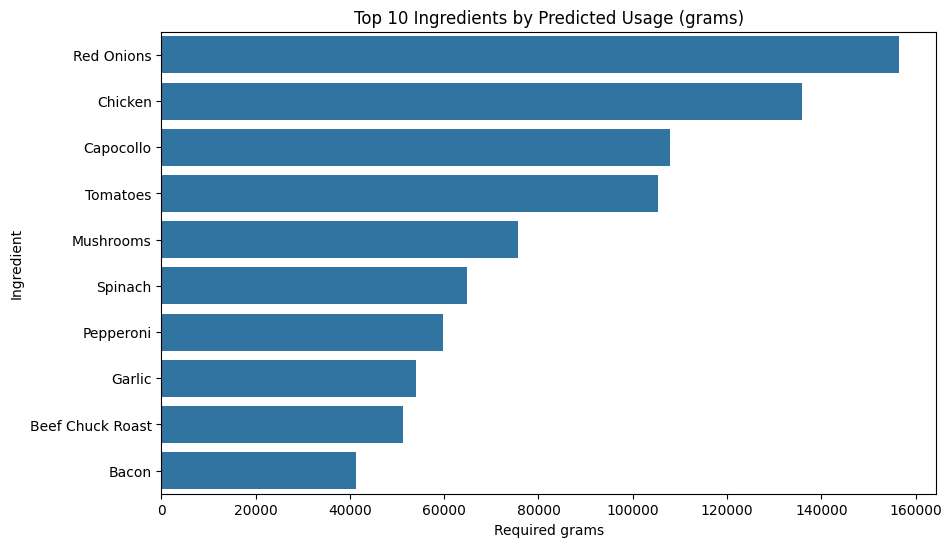

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_ingredients = purchase_plan.sort_values('required_grams', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='required_grams', y='pizza_ingredients', data=top_ingredients)
plt.title("Top 10 Ingredients by Predicted Usage (grams)")
plt.xlabel("Required grams")
plt.ylabel("Ingredient")
plt.show()


In [ ]:
future_sales_df['predicted_quantity'].min()
future_sales_df['predicted_quantity'].max()


2

In [ ]:
# Save future pizza sales
future_sales_df.to_csv(
    "/content/drive/MyDrive/Dominos_project/future_pizza_sales.csv",
    index=False
)

# Save ingredient purchase plan
purchase_plan.to_csv(
    "/content/drive/MyDrive/Dominos_project/ingredient_purchase_plan.csv",
    index=False
)


In [ ]:
import pandas as pd

# Load outputs (replace paths if needed)
future_sales_df = pd.read_csv("/content/drive/MyDrive/Dominos_project/future_pizza_sales.csv")
purchase_plan = pd.read_csv("/content/drive/MyDrive/Dominos_project/ingredient_purchase_plan.csv")
ingredients_df = pd.read_excel("/content/drive/MyDrive/Dominos_project/Pizza_ingredients.xlsx")
sales_df = pd.read_excel("/content/drive/MyDrive/Dominos_project/Pizza_Sale.xlsx")

print("=== FUTURE SALES CHECKS ===")

# 1. Check no zero or negative quantities
if (future_sales_df['predicted_quantity'] <= 0).any():
    print("❌ Found zero or negative predicted quantity!")
else:
    print("✅ All predicted quantities > 0")

# 2. All pizza IDs exist in original data
if set(future_sales_df['pizza_name_id']).issubset(set(sales_df['pizza_name_id'])):
    print("✅ All pizza IDs are valid")
else:
    print("❌ Invalid pizza IDs detected")

# 3. We


=== FUTURE SALES CHECKS ===
✅ All predicted quantities > 0
✅ All pizza IDs are valid


In [ ]:
print("\n=== INGREDIENT PURCHASE PLAN CHECKS ===")

# 1. Required grams > 0
if (purchase_plan['required_grams'] <= 0).any():
    print("❌ Found zero or negative ingredient quantity!")
else:
    print("✅ All ingredient quantities > 0")

# 2. Ingredients exist in original data
if set(purchase_plan['pizza_ingredients']).issubset(set(ingredients_df['pizza_ingredients'])):
    print("✅ All ingredients are valid")
else:
    print("❌ Invalid ingredients detected")

# 3. Logical check for top ingredients
top_ingredients = purchase_plan.sort_values('required_grams', ascending=False).head(10)
print("\nTop 10 ingredients by required grams:")
print(top_ingredients)



=== INGREDIENT PURCHASE PLAN CHECKS ===
❌ Found zero or negative ingredient quantity!
✅ All ingredients are valid

Top 10 ingredients by required grams:
   pizza_ingredients  required_grams
51        Red Onions        156600.0
15           Chicken        135850.0
13         Capocollo        108000.0
62          Tomatoes        105450.0
37         Mushrooms         75600.0
58           Spinach         64830.0
44         Pepperoni         59650.0
25            Garlic         54070.0
9   Beef Chuck Roast         51300.0
6              Bacon         41250.0


In [ ]:
# Filter out zero or missing Items_Qty_In_Grams before calculation
ingredient_forecast = ingredient_forecast[ingredient_forecast['Items_Qty_In_Grams'] > 0].copy()

# Recalculate required grams
ingredient_forecast['required_grams'] = (
    ingredient_forecast['predicted_quantity'] *
    ingredient_forecast['Items_Qty_In_Grams']
)

# Aggregate again
purchase_plan = (
    ingredient_forecast
    .groupby('pizza_ingredients', as_index=False)['required_grams']
    .sum()
)

# Re-run check
if (purchase_plan['required_grams'] <= 0).any():
    print("❌ Still found zero or negative ingredient quantity!")
else:
    print("✅ All ingredient quantities > 0")


✅ All ingredient quantities > 0
